# 대표 통계량

- 라이브러리 설치
    - ```uv add numpy scipy pandas```
- numpy, scipy 학습 : https://wikidocs.net/15636
- pandas 학습 : https://wikidocs.net/135645
- 공식문서 
    - scipy : https://scipy.org/
    - numpy : https://numpy.org/
    - pnadas : https://pandas.pydata.org/

In [1]:
import numpy as np
from scipy import stats
import pandas as pd

## 산술 평균 계산

In [ ]:
# 성적의 평균 구하기
x = [70, 60, 80, 60, 50]
print(np.sum(x)/len(x))
print(np.mean(x))
print(np.array(x).mean())
print(pd.Series(x).mean()) # Pandas에서 series : 1차원 벡터 열

64.0
64.0
64.0
64.0


## 조화 평균 계산

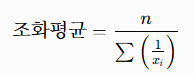

- 조화 평균을 사용하는 대표적인 상황은 어떤것이 있을까?

평균 속도 구하기

In [3]:
# 시간이 같을 때: 산술평균 (총 거리 ÷ 총 시간)
# 문제 : 자동차가 60km/h로 1시간, 40km/h로 1시간 주행을 했을 때
x = np.array([60, 40])
print((60 + 40)/2)
print(np.mean(x))


50.0
50.0


In [ ]:
# 거리가 같을 때: 조화평균 (역수의 산술평균의 역수)
# 문제: 자동차가 60km를 60km/h로 이동하고, 같은 60km를 40km/h로 이동했을 때 평균 속도는?

# Python은 부동소수점 문제가 있음 --> round 시키면 됨.

x = np.array([60, 40])
print(round(len(x) / (1/60 + 1/40), 2))
print(round(len(x) / np.sum(1/x), 2))
print(round(stats.hmean(x), 2))

48.0
48.0
48.0


- 아래 문제는 산술평균 vs 조화평균 어떤 방법이 좋을까?

In [5]:
# 상황: 두 생산 라인이 동일한 수의 제품(작업량)을 생산하지만, 
# 각 라인의 처리 속도가 다를 때 평균 처리 속도를 계산하기

# 라인 A: 60개/시간, 라인 B: 30개/시간  → 동일 작업량(120개 제품 생산) 처리 시 평균 처리속도


In [6]:
import numpy as np
from scipy import stats

rates = np.array([60, 30])  # 처리 속도 (개/시간)
harmonic_mean = len(rates) / np.sum(1/rates)
print(harmonic_mean)  # 출력: 40.0
print(stats.hmean(rates))  # 출력: 40.0

40.0
40.0


## 절사 평균 계산

- 절사 평균는 어떤 상황에서 활용할까요?

In [7]:
# 월 평균이 3백만원이고 표준편차가 50만원인 정규 분포를 따르는 소득을 갖는 100명 생성
income = np.random.normal(3000000, 500000, 100) 
print(round(np.mean(income), 2))

2941875.46


In [8]:
# 월 소득이 1억원인 사람의 등장
# 100명의 소득이 300만원에 가까운데, 한 명 때문에 대표값인 평균이 약 1300만원에 달함
income = np.append(income, 10**9) 
print(round(np.mean(income), 2)) 

12813738.08


#### 절사 평균으로 계산

In [9]:
stats.trim_mean(income, 0.2) # [20% ~ 80%]은 제외하고 계산

np.float64(2944728.578644455)

## 최빈값 계산

- 최빈값은 어떤 상황에서 사용할까요?

In [10]:
x = np.random.choice(['A', 'B', 'C'], 1000) # A, B, C라는 요소로 데이터 1000개 만들기
print(x[:10])
print(len(x))

['A' 'A' 'B' 'B' 'B' 'C' 'C' 'C' 'A' 'A']
1000


In [11]:
# 유니크한 값만 추출
np.unique(x) 

array(['A', 'B', 'C'], dtype='<U1')

In [12]:
pd.Series(x).value_counts()

C    357
B    324
A    319
Name: count, dtype: int64

In [13]:
pd.Series(x).value_counts().index[0] # 맨 앞에 있는 것이 최빈 값

'C'

In [14]:
from collections import Counter
counter = Counter(x)
mode_value, mode_count = counter.most_common(1)[0]  # 최빈값과 빈도수 추출

print("최빈값:", mode_value)
print("최빈값의 빈도수:", mode_count)

최빈값: C
최빈값의 빈도수: 357


## 데이터의 대푯값

In [15]:
import numpy as np
from scipy import stats
import pandas as pd

In [16]:
#np.random.seed(0)
data = np.random.randint(0, 5, 10)
print(data)

mean = np.mean(data); print("평균값 :", mean.round(2))
median = np.median(data); print("중앙값 : ", median)
mode = stats.mode(data); print(f"최빈값 : {mode.mode}, 최빈 횟수 : {mode.count} ")

[1 4 0 1 1 2 2 4 0 0]
평균값 : 1.5
중앙값 :  1.0
최빈값 : 0, 최빈 횟수 : 3 


### pandas로 대푯값 구하기
- 평균값, 중앙값, 최빈값 

In [17]:
import pandas as pd

data = pd.Series([60, 40, 60, 80, 50, 80])
print("평균값 : ", data.mean())
print("중앙값 : ", data.median())
print("최빈값 : ", data.mode())
print("최빈값 : ", data.mode().to_list())

평균값 :  61.666666666666664
중앙값 :  60.0
최빈값 :  0    60
1    80
dtype: int64
최빈값 :  [60, 80]
